In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo


In [4]:
!pip install -U ucimlrepo


In [9]:
import zipfile

with zipfile.ZipFile('/content/sample_data/sms+spam+collection.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [10]:
import os

os.listdir('/content/')

['.config', '.ipynb_checkpoints', 'readme', 'sample_data', 'SMSSpamCollection']

In [11]:
import pandas as pd

df = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

In [12]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
print(df.shape)

(5572, 2)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [15]:
df.isnull().sum()

,0
label,0
message,0


In [16]:
df.duplicated().sum()

np.int64(403)

Missing Value Analysis: No missing values were found in either the label or message columns. Therefore, no rows needed to be removed due to missing values.

In [17]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (5572, 2)


In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['house_size_sqft'], kde=True, color='blue')
plt.title('Distribution of House Size (sqft) with outliers')
plt.xlabel('House Size (sqft)')
plt.ylabel('Frequency')

In [19]:
df = df.drop_duplicates()

In [20]:
print("After removing duplicates:", df.shape)

After removing duplicates: (5169, 2)


In [21]:
print("Duplicates remaining:", df.duplicated().sum())

Duplicates remaining: 0


Duplicate records were then checked using duplicated().sum(). A total of 403 duplicate records were identified and removed using drop_duplicates().

In [22]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Before removing duplicates: (5169, 2)
After removing duplicates: (5169, 2)
Duplicates remaining: 0


In [23]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


In [24]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
ham,87.366996
spam,12.633004


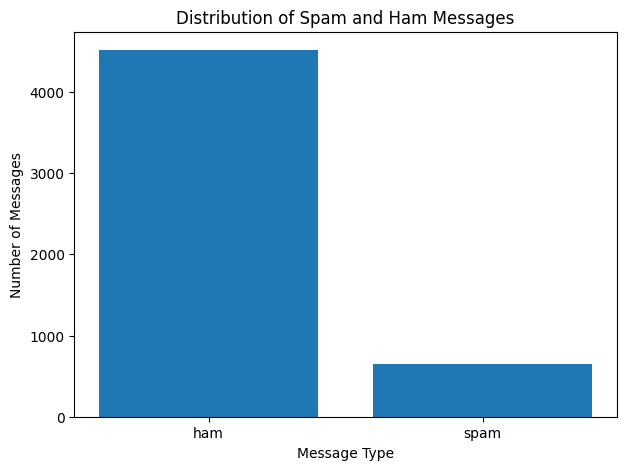

In [25]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(label_counts.index, label_counts.values)

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

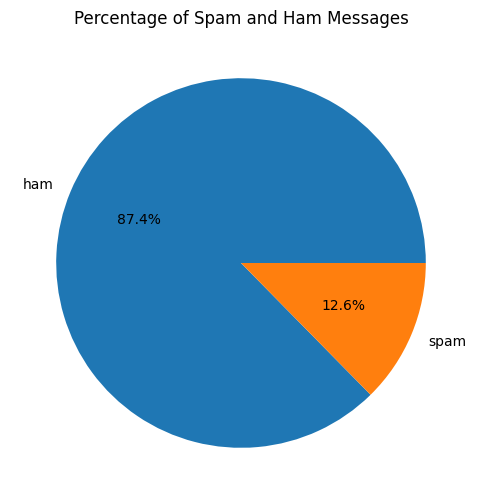

In [26]:
plt.figure(figsize=(6, 6))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%'
)

plt.title('Percentage of Spam and Ham Messages')

plt.show()

lass Distribution Analysis

After removing duplicate records, the dataset contains 5,169 unique SMS messages. There are 4,516 ham messages and 653 spam messages. Therefore, approximately 87.37% of the messages are ham and 12.63% are spam.

The visualization shows that the dataset is imbalanced, as the number of ham messages is significantly higher than the number of spam messages.

In [27]:
df[['label', 'message']].head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [28]:
df['clean_message'] = df['message'].str.lower()

In [29]:
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [30]:
import re

df['clean_message'] = df['clean_message'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [31]:
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now ...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled t...


In [32]:
df['clean_message'] = df['clean_message'].apply(
    lambda x: ' '.join(x.split())
)

In [33]:
df[['label', 'message', 'clean_message']].head(10)

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,ham,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,ham,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,spam,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,spam,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [34]:
df['message_length'] = df['message'].apply(len)

In [35]:
df[['message', 'message_length']].head(10)

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61
5,FreeMsg Hey there darling it's been 3 week's n...,147
6,Even my brother is not like to speak with me. ...,77
7,As per your request 'Melle Melle (Oru Minnamin...,160
8,WINNER!! As a valued network customer you have...,157
9,Had your mobile 11 months or more? U R entitle...,154


In [36]:
df['word_count'] = df['message'].apply(
    lambda x: len(x.split())
)

In [37]:
df[['message', 'word_count']].head(10)

,message,word_count
0,"Go until jurong point, crazy.. Available only ...",20
1,Ok lar... Joking wif u oni...,6
2,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,U dun say so early hor... U c already then say...,11
4,"Nah I don't think he goes to usf, he lives aro...",13
5,FreeMsg Hey there darling it's been 3 week's n...,32
6,Even my brother is not like to speak with me. ...,16
7,As per your request 'Melle Melle (Oru Minnamin...,26
8,WINNER!! As a valued network customer you have...,26
9,Had your mobile 11 months or more? U R entitle...,29


In [38]:
df['digit_count'] = df['message'].apply(
    lambda x: sum(c.isdigit() for c in x)
)

In [39]:
df[['message', 'digit_count']].head(10)

,message,digit_count
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,25
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
5,FreeMsg Hey there darling it's been 3 week's n...,4
6,Even my brother is not like to speak with me. ...,0
7,As per your request 'Melle Melle (Oru Minnamin...,1
8,WINNER!! As a valued network customer you have...,19
9,Had your mobile 11 months or more? U R entitle...,13


In [40]:
df['uppercase_count'] = df['message'].apply(
    lambda x: sum(c.isupper() for c in x)
)

In [41]:
df[['message', 'uppercase_count']].head(10)

,message,uppercase_count
0,"Go until jurong point, crazy.. Available only ...",3
1,Ok lar... Joking wif u oni...,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,10
3,U dun say so early hor... U c already then say...,2
4,"Nah I don't think he goes to usf, he lives aro...",2
5,FreeMsg Hey there darling it's been 3 week's n...,7
6,Even my brother is not like to speak with me. ...,2
7,As per your request 'Melle Melle (Oru Minnamin...,10
8,WINNER!! As a valued network customer you have...,12
9,Had your mobile 11 months or more? U R entitle...,14


In [42]:
df.head()

,label,message,clean_message,message_length,word_count,digit_count,uppercase_count
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20,0,3
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6,0,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,155,28,25,10
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11,0,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13,0,2


In [43]:
df[['message_length',
    'word_count',
    'digit_count',
    'uppercase_count']].describe()

,message_length,word_count,digit_count,uppercase_count
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,79.344554,15.439930,2.215902,5.407816
std,58.437457,11.117073,6.031250,11.778663
min,2.000000,1.000000,0.000000,0.000000
25%,36.000000,7.000000,0.000000,1.000000
50%,61.000000,12.000000,0.000000,2.000000
75%,119.000000,22.000000,1.000000,4.000000
max,910.000000,171.000000,47.000000,138.000000


You have 5,169 unique messages.

Your numerical features are:

Feature	Mean	Min	Max
Message length	79.34	2	910
Word count	15.44	1	171
Digit count	2.22	0	47
Uppercase count	5.41	0	138

The first thing that jumps out is:

Typical message length: around 79 characters
Maximum message length: 910 characters

Similarly:

Typical word count: around 15 words
Maximum: 171 words

Those maximum values are potentially unusual observations.

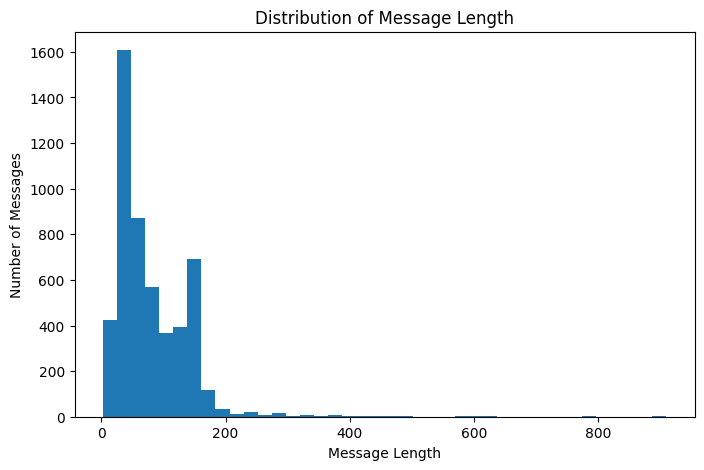

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['message_length'], bins=40)

plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Number of Messages')

plt.show()

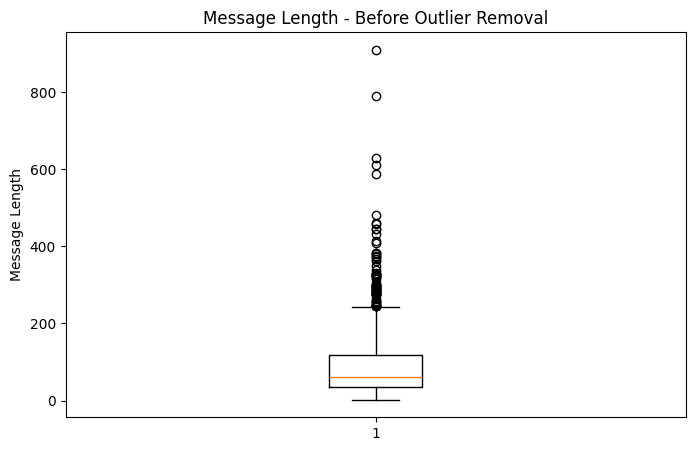

In [45]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['message_length'])

plt.title('Message Length - Before Outlier Removal')
plt.ylabel('Message Length')

plt.show()

In [46]:
Q1 = df['message_length'].quantile(0.25)
Q3 = df['message_length'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 36.0
Q3: 119.0
IQR: 83.0
Lower Bound: -88.5
Upper Bound: 243.5


In [47]:
outliers = df[
    (df['message_length'] < lower_bound) |
    (df['message_length'] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 64


In [48]:
print("Percentage of potential outliers:",
      len(outliers) / len(df) * 100)

Percentage of potential outliers: 1.2381505126716965


In [49]:
outliers[['label', 'message', 'message_length']].head(20)

,label,message,message_length
53,ham,Wow. I never realized that you were so embaras...,289
127,ham,"Just so that you know,yetunde hasn't sent mone...",244
155,ham,"You are everywhere dirt, on the floor, the win...",384
381,ham,I guess that's why you re worried. You must kn...,300
425,ham,Send this to ur friends and receive something ...,248
473,ham,Nothing. I meant that once the money enters yo...,298
551,ham,Imagine you finally get to sink into that bath...,281
711,ham,Height of Confidence: All the Aeronautics prof...,316
838,ham,"Sir, I have been late in paying rent for the p...",372
882,ham,"see, i knew giving you a break a few times wou...",276


In [50]:
df_before_outliers = df.copy()

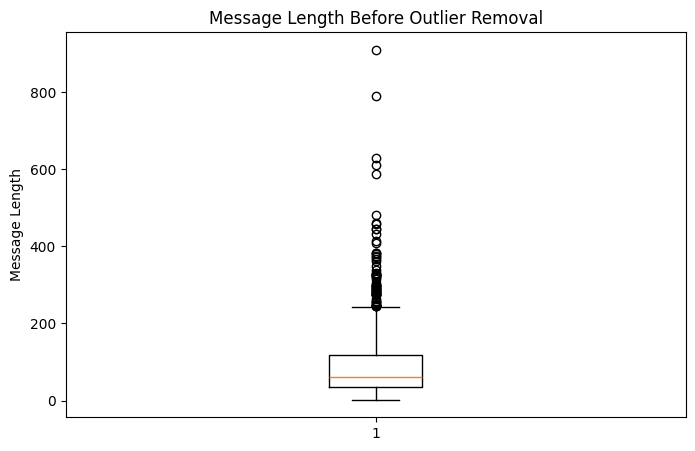

In [51]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_before_outliers['message_length'])

plt.title('Message Length Before Outlier Removal')
plt.ylabel('Message Length')

plt.show()

In [52]:
print("Number of potential outliers:", len(outliers))

Number of potential outliers: 64


In [53]:
outliers[['label', 'message', 'message_length']].head(20)

,label,message,message_length
53,ham,Wow. I never realized that you were so embaras...,289
127,ham,"Just so that you know,yetunde hasn't sent mone...",244
155,ham,"You are everywhere dirt, on the floor, the win...",384
381,ham,I guess that's why you re worried. You must kn...,300
425,ham,Send this to ur friends and receive something ...,248
473,ham,Nothing. I meant that once the money enters yo...,298
551,ham,Imagine you finally get to sink into that bath...,281
711,ham,Height of Confidence: All the Aeronautics prof...,316
838,ham,"Sir, I have been late in paying rent for the p...",372
882,ham,"see, i knew giving you a break a few times wou...",276


In [54]:
df_after_outliers = df[
    (df['message_length'] >= lower_bound) &
    (df['message_length'] <= upper_bound)
].copy()

In [55]:
print("Before outlier removal:", df.shape)
print("After outlier removal:", df_after_outliers.shape)

Before outlier removal: (5169, 7)
After outlier removal: (5105, 7)


In [56]:
print(
    "Outliers remaining:",
    len(df_after_outliers[
        df_after_outliers['message_length'] > upper_bound
    ])
)

Outliers remaining: 0


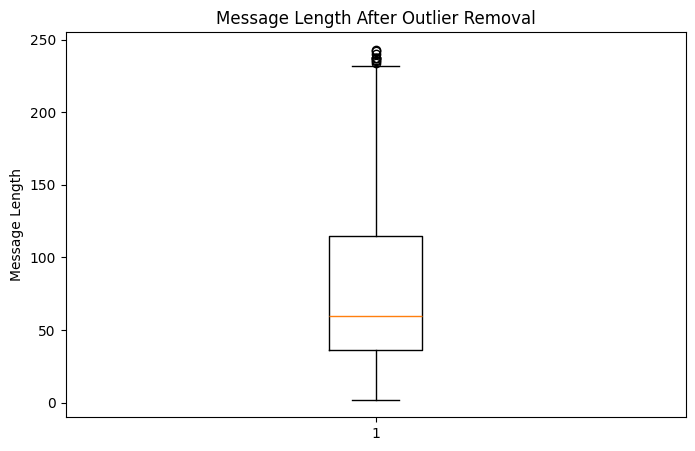

In [57]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_after_outliers['message_length'])

plt.title('Message Length After Outlier Removal')
plt.ylabel('Message Length')

plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7a626d1f9d60>,
 'caps': [<matplotlib.lines.Line2D at 0x7a626d1fbb60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a626d1fa600>],
 'medians': [<matplotlib.lines.Line2D at 0x7a626d1fbd10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a6284b0fcb0>],
 'means': []}

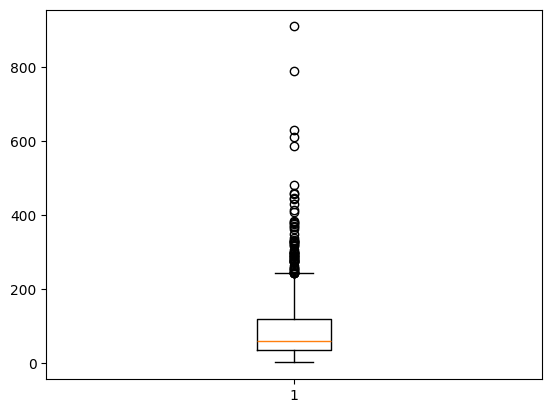

In [58]:
plt.boxplot(df_before_outliers['message_length'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7a626ced6900>,
 'caps': [<matplotlib.lines.Line2D at 0x7a626ced4590>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a626cfc5fd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a6284ad7aa0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a626ced62a0>],
 'means': []}

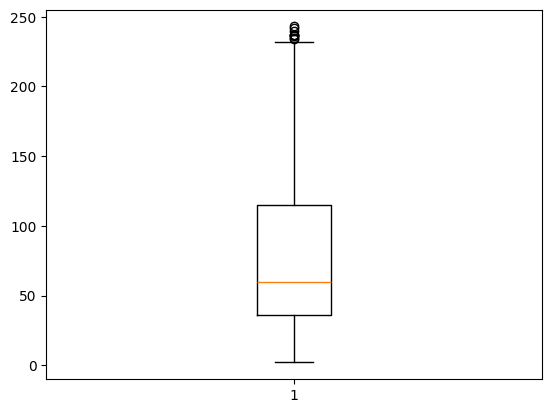

In [59]:
plt.boxplot(df_after_outliers['message_length'])

In [60]:
print(df_before_outliers['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


In [61]:
print(
    df_after_outliers['label'].value_counts(normalize=True) * 100
)

label
ham     87.208619
spam    12.791381
Name: proportion, dtype: float64


In [62]:
print("Before:", df_before_outliers.shape)
print("After:", df_after_outliers.shape)

Before: (5169, 7)
After: (5105, 7)


In [63]:
print("Before:")
print(df_before_outliers['label'].value_counts())

print("\nAfter:")
print(df_after_outliers['label'].value_counts())

Before:
label
ham     4516
spam     653
Name: count, dtype: int64

After:
label
ham     4452
spam     653
Name: count, dtype: int64


In [64]:
print("Original rows:", len(df))
print("After removal:", len(df_after_outliers))

print("Rows removed:", len(df) - len(df_after_outliers))

Original rows: 5169
After removal: 5105
Rows removed: 64


In [65]:
removed_rows = df.loc[~df.index.isin(df_after_outliers.index)]

print(removed_rows['label'].value_counts())
print("Number removed:", len(removed_rows))

label
ham    64
Name: count, dtype: int64
Number removed: 64


In [66]:
print("Number of outliers detected originally:", len(outliers))

Number of outliers detected originally: 64


In [67]:
df_before_outliers

,label,message,clean_message,message_length,word_count,digit_count,uppercase_count
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20,0,3
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6,0,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,155,28,25,10
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11,0,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13,0,2
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,this is the nd time we have tried contact u u ...,160,30,21,9
5568,ham,Will ü b going to esplanade fr home?,will b going to esplanade fr home,36,8,0,1
5569,ham,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggestions,57,10,0,2
5570,ham,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...,125,26,0,2


In [68]:
df_before_outliers[['label', 'clean_message']].head()

,label,clean_message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [69]:
X_before = df_before_outliers['clean_message']
y_before = df_before_outliers['label']

In [70]:
from sklearn.model_selection import train_test_split

X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(
    X_before,
    y_before,
    test_size=0.2,
    random_state=42,
    stratify=y_before
)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
vectorizer_before = TfidfVectorizer()

In [74]:
X_train_before_tfidf = vectorizer_before.fit_transform(
    X_train_before
)

In [75]:
X_test_before_tfidf = vectorizer_before.transform(
    X_test_before
)

In [78]:
from sklearn.naive_bayes import MultinomialNB

model_before = MultinomialNB()

model_before.fit(
    X_train_before_tfidf,
    y_train_before
)

MultinomialNB()

In [79]:
y_pred_before = model_before.predict(
    X_test_before_tfidf
)

In [80]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy_before = accuracy_score(
    y_test_before,
    y_pred_before
)

print("Accuracy:", accuracy_before)

Accuracy: 0.9477756286266924


In [81]:
print(
    classification_report(
        y_test_before,
        y_pred_before
    )
)

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       903
        spam       1.00      0.59      0.74       131

    accuracy                           0.95      1034
   macro avg       0.97      0.79      0.86      1034
weighted avg       0.95      0.95      0.94      1034



In [82]:
print(
    classification_report(
        y_test_before,
        y_pred_before
    )
)

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       903
        spam       1.00      0.59      0.74       131

    accuracy                           0.95      1034
   macro avg       0.97      0.79      0.86      1034
weighted avg       0.95      0.95      0.94      1034



In [83]:
cm_before = confusion_matrix(
    y_test_before,
    y_pred_before
)

print(cm_before)

[[903   0]
 [ 54  77]]


In [84]:
df_after_outliers

,label,message,clean_message,message_length,word_count,digit_count,uppercase_count
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20,0,3
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6,0,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,155,28,25,10
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11,0,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13,0,2
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,this is the nd time we have tried contact u u ...,160,30,21,9
5568,ham,Will ü b going to esplanade fr home?,will b going to esplanade fr home,36,8,0,1
5569,ham,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggestions,57,10,0,2
5570,ham,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...,125,26,0,2


In [85]:
X_after = df_after_outliers['clean_message']
y_after = df_after_outliers['label']

In [86]:
X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_after,
    y_after,
    test_size=0.2,
    random_state=42,
    stratify=y_after
)

In [87]:
vectorizer_after = TfidfVectorizer()

X_train_after_tfidf = vectorizer_after.fit_transform(
    X_train_after
)

X_test_after_tfidf = vectorizer_after.transform(
    X_test_after
)

In [88]:
model_after = MultinomialNB()

model_after.fit(
    X_train_after_tfidf,
    y_train_after
)

MultinomialNB()

In [89]:
y_pred_after = model_after.predict(
    X_test_after_tfidf
)

In [90]:
accuracy_after = accuracy_score(
    y_test_after,
    y_pred_after
)

print("Accuracy:", accuracy_after)

Accuracy: 0.9461312438785504


In [91]:
print(
    classification_report(
        y_test_after,
        y_pred_after
    )
)

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       890
        spam       1.00      0.58      0.73       131

    accuracy                           0.95      1021
   macro avg       0.97      0.79      0.85      1021
weighted avg       0.95      0.95      0.94      1021



In [92]:
cm_after = confusion_matrix(
    y_test_after,
    y_pred_after
)

print(cm_after)

[[890   0]
 [ 55  76]]


1. Your final comparison
Metric	Before Outlier Removal	After Outlier Removal	Change
Accuracy	94.78%	94.61%	↓ 0.16%
Spam Precision	100%	100%	No change
Spam Recall	59%	58%	↓ 1%
Spam F1-score	74%	73%	↓ 1%
Spam correctly detected	77	76	↓ 1
Spam missed	54	55	↑ 1

Your confusion matrices were:

Before:

[[903   0]
 [ 54  77]]

After:

[[890   0]
 [ 55  76]]